<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB6 — GEMEX: Geodesic Entropic Manifold Explainability</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 (Bonus NB) | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

---

## Why GEMEX?

SHAP, LIME, MAPLE, and Integrated Gradients all share one hidden assumption: the path from a reference point to the query point is a **straight line in Euclidean space**.

> Machine learning models define **statistical manifolds** governed by complex Riemannian curvature. Straight-line attributions through curved space generate geometrically incorrect explanations.

**GEMEX** (Geodesic Entropic Manifold Explainability) is the first XAI framework grounded strictly in Riemannian information geometry. It computes explanations along the **true shortest path** (geodesic) on the Fisher information manifold.

```
pip install gemex | github.com/utkukose/gemex
Playground: https://utkukose.github.io/gemex_playground/
```

## What this notebook covers

| Section | Content |
|---|---|
| 1 | Setup and imports |
| 2 | The geometric motivation — why flat-space XAI is wrong |
| 3 | Dataset (Cleveland Heart Disease) and model (Random Forest) |
| 4 | SHAP — TreeSHAP attribution baseline |
| 5 | LIME — local linear approximation |
| 6 | MAPLE — model-agnostic prediction local explanation |
| 7 | GEMEX — geodesic attribution on the Fisher manifold |
| 8 | Four-method side-by-side comparison |
| 9 | GEMEX exclusive capabilities (PTI, FAS, BTD, curvature) |
| 10 | Pima Diabetes cross-domain comparison |
| 11 | Summary and final comparison table |


## Section 1 — Setup

In [53]:
# Uncomment if any package is missing:
# !pip install gemex shap lime scikit-learn matplotlib pandas --quiet


In [ ]:
%matplotlib inline
from IPython.display import display

In [54]:
import warnings; warnings.filterwarnings('ignore')
import os, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams

rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.spines.top':False, 'axes.spines.right':False,
    'font.size':11,
})
ACCENT='#E84855'; SAFE='#27AE60'; NEUTRAL='#2E75B6'
GEMEX_COLOR='#7B2FBE'; SHAP_COLOR='#FF6B35'
LIME_COLOR='#1ABC9C'; MAPLE_COLOR='#F39C12'
MODEL_COLORS = {'RF':'#2E75B6','LR':'#27AE60','MLP':'#E84855','SVM':'#9B59B6'}

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import shap
import lime, lime.lime_tabular
import gemex
from gemex import Explainer, GemexConfig

print(f"GEMEX  {gemex.__version__}")
print(f"SHAP   {shap.__version__}")
import importlib.metadata
try:    print(f"LIME   {importlib.metadata.version('lime')}")
except: print("LIME   (version check unavailable)")


GEMEX  1.2.2
SHAP   0.51.0
LIME   0.2.0.1


## Section 2 — The Geometric Motivation

### The Fundamental Fallacy

All classical XAI methods draw a **straight Euclidean line** from a baseline x* to the query x, then measure contributions along it:

**SHAP** (Lundberg & Lee, NeurIPS 2017):
$$\phi_i = \int_0^1 \frac{\partial f}{\partial x_i}\bigl(x^* + t(x - x^*)\bigr)\,dt$$

**Integrated Gradients** (Sundararajan et al., ICML 2017) uses the same linear path.
**LIME** (Ribeiro et al., KDD 2016) fits a local linear model around x in Euclidean space.
**MAPLE** (Plumb et al., NeurIPS 2018) uses a linear model on locally-weighted features.

**The geometric reality:** ML models define statistical manifolds with Riemannian curvature governed by the **Fisher Information Matrix**:

$$G_{ir}(x) = \sum_y p(y|x)\cdot\frac{\partial \log p(y|x)}{\partial x_i}\cdot\frac{\partial \log p(y|x)}{\partial x_r}$$

By **Chentsov's theorem** (1972), this is the *unique natural metric tensor* of the statistical manifold. Straight-line attribution through this curved space is geometrically incorrect.

### The GEMEX Solution

GEMEX integrates along the **true geodesic** γ(t) under the Fisher metric:

$$\text{GSF}_i(x) = \int_0^1 \frac{\langle \gamma'(t), \mathbf{e}_i \rangle_G}{\|\gamma'(t)\|_G\,\|\mathbf{e}_i\|_G}\,\|\gamma'(t)\|_G\,\omega(t)\,dt$$

**Key guarantee:** GSF is **reparametrisation-invariant** — rescaling a feature (e.g. blood pressure from mmHg to kPa) cannot alter its attribution score. SHAP, LIME, MAPLE, and IG cannot guarantee this.


## Section 3 — Dataset and Models

**Dataset:** Cleveland Heart Disease (UCI ML Repository, ID 45).
Place `cleveland_heart.csv` in the same folder as this notebook.

**Models trained in Section 3B:**

| Model | Decision surface | GEMEX config | Why GEMEX findings differ |
|---|---|---|---|
| **RF** | Piecewise-constant (step functions) | `fim_epsilon=0.05`, auto=False | Curvature is concentrated at leaf boundaries; geodesic deviates most from SHAP, LIME, and MAPLE |
| **LR** | Linear hyperplane | `fim_epsilon_auto=True` | Nearly flat Fisher manifold; GSF ≈ scaled gradient — GEMEX closely agrees with SHAP, LIME, and MAPLE |
| **MLP** | Smooth nonlinear | `fim_epsilon_auto=True` | Intermediate curvature; GEMEX, SHAP, LIME, and MAPLE agree on top features but differ in magnitude |
| **SVM** | RBF kernel boundary | `fim_epsilon_auto=True` | High curvature near support vectors; strongest PTI holonomy interactions |


In [55]:
# ── Load Cleveland Heart Disease ─────────────────────────────────────────────
FILE_B = 'cleveland_heart.csv'
COLS_B = ['age','sex','cp','trestbps','chol','fbs','restecg',
          'thalach','exang','oldpeak','slope','ca','thal','target']

if not os.path.exists(FILE_B):
    raise FileNotFoundError(
        f"'{FILE_B}' not found. Place it in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets/master/heart-disease.csv")

data = pd.read_csv(FILE_B)
if 'target' not in data.columns: data.columns = COLS_B
data['target'] = data['target'].astype(int)
data = data.astype(float); data['target'] = data['target'].astype(int)

FEAT = [c for c in data.columns if c != 'target']
FEAT_LABELS = {
    'age':'Age (years)', 'sex':'Sex (1=M,0=F)', 'cp':'Chest pain type (0-3)',
    'trestbps':'Resting BP (mmHg)', 'chol':'Cholesterol (mg/dL)',
    'fbs':'Fasting glucose >120', 'restecg':'Resting ECG (0-2)',
    'thalach':'Max heart rate', 'exang':'Exercise angina (0/1)',
    'oldpeak':'ST depression', 'slope':'Peak ST slope',
    'ca':'Major vessels (0-3)', 'thal':'Thalassemia type',
}

X = data[FEAT].values; y = data['target'].values
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
Xtr = Xtr.astype(float); Xte = Xte.astype(float)

print(f"Cleveland Heart Disease: {len(data)} patients | Disease: {y.mean():.1%}")
print(f"Train: {len(Xtr)} | Test: {len(Xte)}")
print(f"Features ({len(FEAT)}): {FEAT}")


Cleveland Heart Disease: 297 patients | Disease: 46.1%
Train: 237 | Test: 60
Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [56]:
# ── Section 3B: Train RF, LR, MLP, SVM ───────────────────────────────────────
# StandardScaler is required for LR, MLP, and SVM but NOT for RF.
# Both scaled and unscaled arrays are kept so that GEMEX, SHAP, LIME, and MAPLE
# each operate on the correct input space for their model.

scaler = StandardScaler().fit(Xtr)
Xtr_s  = scaler.transform(Xtr)      # scaled training set  (LR / MLP / SVM)
Xte_s  = scaler.transform(Xte)      # scaled test set

MODEL_SURFACE = {
    'RF' : 'Piecewise-constant',
    'LR' : 'Linear hyperplane',
    'MLP': 'Smooth nonlinear',
    'SVM': 'RBF kernel boundary',
}

# Train all 4 models
rf  = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42).fit(Xtr,   ytr)
lr  = LogisticRegression(C=1.0, max_iter=1000, random_state=42)          .fit(Xtr_s, ytr)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                    max_iter=500, random_state=42)                         .fit(Xtr_s, ytr)
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True,
          random_state=42)                                                 .fit(Xtr_s, ytr)

# Convenience lookup: model object and its training/test arrays
MODELS = {
    'RF' : (rf,  Xtr,   Xte),
    'LR' : (lr,  Xtr_s, Xte_s),
    'MLP': (mlp, Xtr_s, Xte_s),
    'SVM': (svm, Xtr_s, Xte_s),
}

print(f"{'Model':<6}  {'Test AUC':>9}  {'5-fold CV':>12}  {'Surface'}")
print("-" * 58)
for name, (model, Xtr_m, Xte_m) in MODELS.items():
    auc = roc_auc_score(yte, model.predict_proba(Xte_m)[:,1])
    cv  = cross_val_score(model,
              np.vstack([Xtr_m, Xte_m]),
              np.concatenate([ytr, yte]),
              cv=5, scoring='roc_auc')
    print(f"{name:<6}  {auc:>9.3f}  {cv.mean():>6.3f}±{cv.std():.3f}  "
          f"{MODEL_SURFACE[name]}")

# Canonical patient selection uses RF (unscaled) for reproducibility.
# Sections 4-8 use RF. Section 9 extends to all 4 models.
d_indices = [i for i in range(len(Xte))
             if yte[i]==1 and rf.predict_proba(Xte[i:i+1])[0,1] > 0.70]
n_indices = [i for i in range(len(Xte))
             if yte[i]==0 and rf.predict_proba(Xte[i:i+1])[0,1] < 0.15]
pat_d  = Xte[d_indices[0]];   pat_d_s = Xte_s[d_indices[0]]
pat_n  = Xte[n_indices[0]];   pat_n_s = Xte_s[n_indices[0]]
risk_d = rf.predict_proba(pat_d.reshape(1,-1))[0,1]
risk_n = rf.predict_proba(pat_n.reshape(1,-1))[0,1]

print(f"\nPatient D — True: Disease     | RF predicted risk: {risk_d:.1%}")
print(f"Patient N — True: No Disease  | RF predicted risk: {risk_n:.1%}")


Model    Test AUC     5-fold CV  Surface
----------------------------------------------------------
RF          0.929   0.906±0.046  Piecewise-constant
LR          0.950   0.895±0.068  Linear hyperplane
MLP         0.881   0.861±0.048  Smooth nonlinear
SVM         0.893   0.858±0.055  RBF kernel boundary

Patient D — True: Disease     | RF predicted risk: 75.1%
Patient N — True: No Disease  | RF predicted risk: 5.3%


## Section 4 — SHAP (TreeSHAP)

SHAP assigns each feature a value representing its contribution to the prediction
relative to the expected model output. For tree models, TreeSHAP computes exact
Shapley values in polynomial time via tree path enumeration.

**Axioms satisfied:** efficiency, symmetry, dummy, additivity.
**Path assumption:** straight Euclidean line from mean baseline to x.
**Reference:** Lundberg & Lee, NeurIPS 2017.


SHAP baseline (population expected value): +0.4663

Patient D — top SHAP drivers:
  oldpeak         +0.1853  ↑ risk
  ca              +0.1401  ↑ risk
  cp              -0.1069  ↓ risk
  thal            +0.0954  ↑ risk
  slope           -0.0735  ↓ risk

Patient N — top SHAP drivers:
  cp              -0.1022  ↓ risk
  thal            -0.0617  ↓ risk
  ca              -0.0574  ↓ risk
  slope           -0.0450  ↓ risk
  thalach         -0.0447  ↓ risk


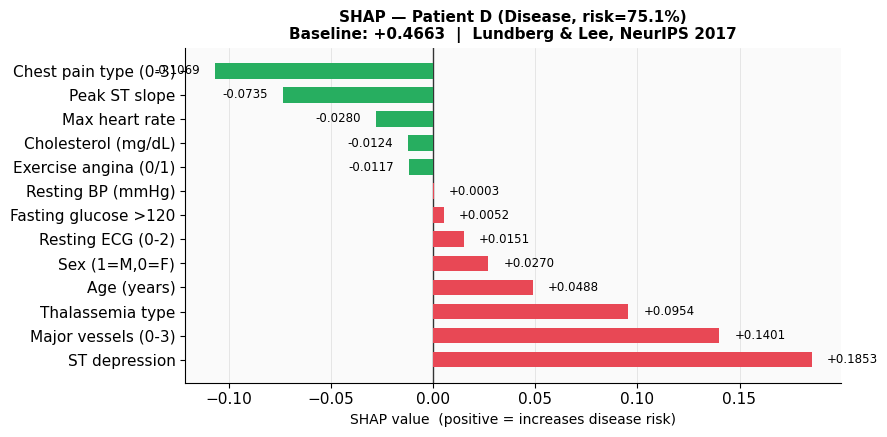

In [57]:
# ── Compute SHAP ─────────────────────────────────────────────────────────────
shap_exp   = shap.TreeExplainer(rf)
shap_bline = float(np.array(shap_exp.expected_value).flat[-1])

sv_d = np.array(shap_exp.shap_values(pat_d.reshape(1,-1)))
sv_n = np.array(shap_exp.shap_values(pat_n.reshape(1,-1)))
if sv_d.ndim == 3: sv_d = sv_d[:,:,1]; sv_n = sv_n[:,:,1]
sv_d = sv_d[0]; sv_n = sv_n[0]
shap_d = dict(zip(FEAT, sv_d))
shap_n = dict(zip(FEAT, sv_n))

print(f"SHAP baseline (population expected value): {shap_bline:+.4f}")
print()
print(f"Patient D — top SHAP drivers:")
for feat, val in sorted(shap_d.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    direct = '↑ risk' if val > 0 else '↓ risk'
    print(f"  {feat:<15} {val:+.4f}  {direct}")
print()
print(f"Patient N — top SHAP drivers:")
for feat, val in sorted(shap_n.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    direct = '↑ risk' if val > 0 else '↓ risk'
    print(f"  {feat:<15} {val:+.4f}  {direct}")

# SHAP plot — waterfall for Patient D
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_facecolor('#FAFAFA')
sorted_d = sorted(shap_d.items(), key=lambda x: x[1])
fs = [FEAT_LABELS.get(f,f) for f,_ in sorted_d]
vs = [v for _,v in sorted_d]
maxabs = max(abs(v) for v in vs) or 1
colors = [SAFE if v < 0 else ACCENT for v in vs]
ax.barh(fs, vs, color=colors, height=0.65, edgecolor='none', zorder=3)
ax.axvline(0, color='#333', linewidth=1, zorder=2)
ax.set_xlabel('SHAP value  (positive = increases disease risk)', fontsize=10)
ax.set_title(f'SHAP — Patient D (Disease, risk={risk_d:.1%})\n'
             f'Baseline: {shap_bline:+.4f}  |  Lundberg & Lee, NeurIPS 2017',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', linewidth=0.4, alpha=0.5)
ax.invert_yaxis()
for i,(f,v) in enumerate(sorted_d):
    ax.text(v+(maxabs*0.04 if v>=0 else -maxabs*0.04), i, f'{v:+.4f}',
            va='center', ha='left' if v>=0 else 'right', fontsize=8.5)
plt.tight_layout(); plt.show(); plt.close()


## Section 5 — LIME

LIME fits a sparse **local linear model** around the query point by generating perturbed
samples in the neighbourhood of x, weighting them by proximity (cosine similarity),
and training an interpretable surrogate.

**Path assumption:** local Euclidean neighbourhood around x.
**Limitation:** stability varies between runs (stochastic sampling).
**Reference:** Ribeiro, Singh & Guestrin, KDD 2016.


LIME local prediction (Patient D): 75.1%

Patient D — top LIME drivers:
  cp <= 3.00                               -0.1943
  oldpeak > 1.80                           +0.1712
  ca > 1.00                                +0.1553
  3.00 < thal <= 7.00                      +0.1473
  slope <= 1.00                            -0.0909


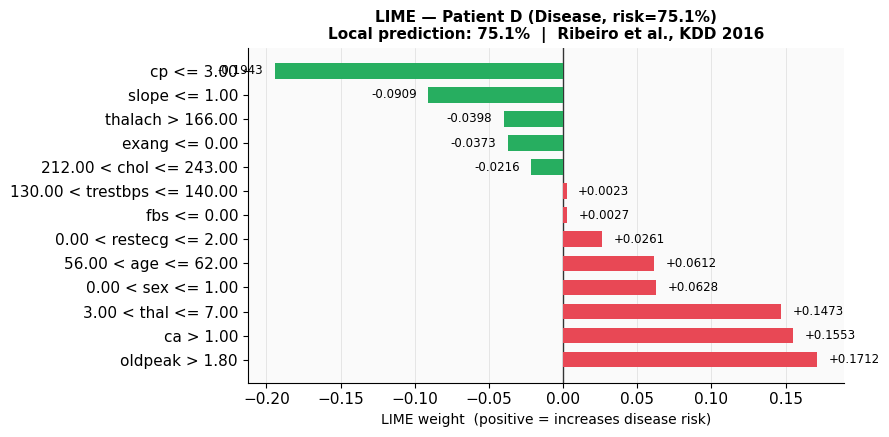


LIME stability (5 independent runs, num_samples=500):
  Most variable conditions (std across 5 runs):
    std=0.0121  oldpeak > 1.80
    std=0.0103  ca > 1.00
    std=0.0098  slope <= 1.00
  Note: High std reflects LIME instability due to random sampling.
  MAPLE and GEMEX are deterministic — no sampling variability.


In [58]:
# ── Compute LIME ─────────────────────────────────────────────────────────────
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    Xtr, feature_names=FEAT,
    class_names=['No Disease','Disease'],
    discretize_continuous=True, random_state=42)

lr_d = lime_exp.explain_instance(pat_d, rf.predict_proba, num_features=len(FEAT))
lr_n = lime_exp.explain_instance(pat_n, rf.predict_proba, num_features=len(FEAT))
lime_d = dict(lr_d.as_list())
lime_n = dict(lr_n.as_list())

print(f"LIME local prediction (Patient D): {lr_d.predict_proba[1]:.1%}")
print()
print("Patient D — top LIME drivers:")
for cond, w in sorted(lime_d.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    print(f"  {cond[:40]:<40} {w:+.4f}")

# LIME plot — Patient D
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_facecolor('#FAFAFA')
sorted_lime = sorted(lime_d.items(), key=lambda x: x[1])
labels_l = [k[:40] for k,_ in sorted_lime]
vals_l   = [v for _,v in sorted_lime]
maxabs_l = max(abs(v) for v in vals_l) or 1
colors_l = [SAFE if v < 0 else ACCENT for v in vals_l]
ax.barh(labels_l, vals_l, color=colors_l, height=0.65, edgecolor='none', zorder=3)
ax.axvline(0, color='#333', linewidth=1)
ax.set_xlabel('LIME weight  (positive = increases disease risk)', fontsize=10)
ax.set_title(f'LIME — Patient D (Disease, risk={risk_d:.1%})\n'
             f'Local prediction: {lr_d.predict_proba[1]:.1%}  |  Ribeiro et al., KDD 2016',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', linewidth=0.4, alpha=0.5)
ax.invert_yaxis()
for i,(_,v) in enumerate(sorted_lime):
    ax.text(v+(maxabs_l*0.04 if v>=0 else -maxabs_l*0.04), i, f'{v:+.4f}',
            va='center', ha='left' if v>=0 else 'right', fontsize=8.5)
plt.tight_layout(); plt.show(); plt.close()

# LIME stability across 5 runs
print("\nLIME stability (5 independent runs, num_samples=500):")
runs = []
for seed in range(5):
    exp_s = lime.lime_tabular.LimeTabularExplainer(
        Xtr, feature_names=FEAT, class_names=['No Disease','Disease'],
        discretize_continuous=True, random_state=seed)
    r = exp_s.explain_instance(pat_d, rf.predict_proba, num_features=5, num_samples=500)
    runs.append(dict(r.as_list()))
all_keys = set(k for r in runs for k in r)
stds = {k: np.std([r.get(k,0) for r in runs]) for k in all_keys}
top_unstable = sorted(stds.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"  Most variable conditions (std across 5 runs):")
for cond, std in top_unstable:
    print(f"    std={std:.4f}  {cond[:50]}")
print("  Note: High std reflects LIME instability due to random sampling.")
print("  MAPLE and GEMEX are deterministic — no sampling variability.")


## Section 6 — MAPLE

MAPLE (Model Agnostic Prediction Local Explanation) combines a Random Forest
surrogate with locally-weighted linear regression. For each query point, it:
1. Uses a surrogate RF to find which training samples fall in the same leaves
2. Computes sample weights from co-occurrence in leaves (proximity measure)
3. Fits a weighted Ridge regression to those samples
4. Returns the regression coefficients as feature attributions

**Path assumption:** locally-weighted Euclidean linear model.
**Advantage over LIME:** deterministic; not sensitive to random sampling.
**Reference:** Plumb, Molitor & Talwalkar, NeurIPS 2018.


MAPLE local prediction (Patient D): 77.4%
MAPLE local prediction (Patient N): 0.1%

Patient D — top MAPLE attributions:
  sex             +0.1024  ↑ risk
  oldpeak         +0.0919  ↑ risk
  ca              +0.0842  ↑ risk
  slope           +0.0829  ↑ risk
  cp              +0.0805  ↑ risk


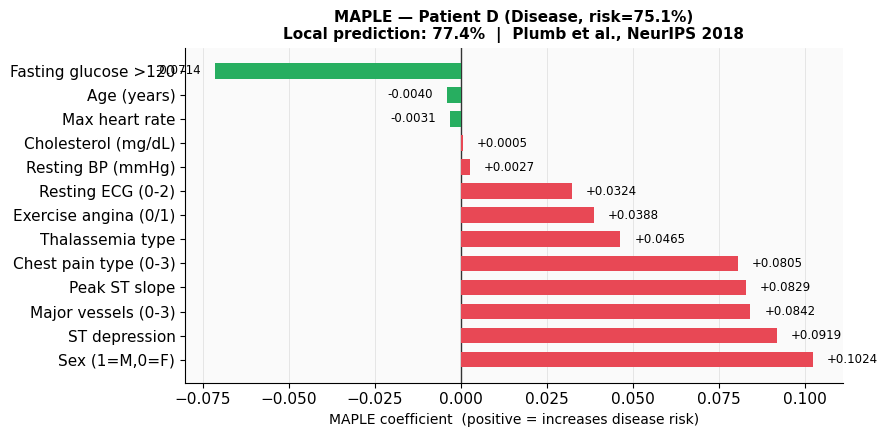


MAPLE stability (5 runs — same result each time because it is deterministic):
  Run 1: top = sex = +0.1024
  Run 2: top = sex = +0.1024
  Run 3: top = sex = +0.1024
  Run 4: top = sex = +0.1024
  Run 5: top = sex = +0.1024
  ✓ Fully deterministic — unlike LIME which varies between runs.


In [59]:
# ── MAPLE implementation (sklearn-based) ─────────────────────────────────────
# The original MAPLE paper uses a Random Forest surrogate fitted to the
# black-box model's predictions, then extracts leaf-based sample weights.

def maple_explain(model, patient, X_train, feature_names,
                  n_trees=100, max_depth=5, alpha=0.01):
    """
    MAPLE: Model Agnostic Prediction Local Explanation.
    Reference: Plumb, Molitor & Talwalkar, NeurIPS 2018.

    1. Fit RF regressor on model's predicted probabilities
    2. Co-leaf weighting: w_i = (# trees where sample i and patient share a leaf)
    3. Weighted Ridge regression → coefficients = local feature attributions
    """
    # Step 1 — surrogate RF on model outputs
    rf_surr = RandomForestRegressor(n_estimators=n_trees, max_depth=max_depth,
                                     random_state=42)
    preds_train = model.predict_proba(X_train)[:, 1]
    rf_surr.fit(X_train, preds_train)

    # Step 2 — co-leaf proximity weights
    pat_leaves   = rf_surr.apply(patient.reshape(1,-1))[0]      # (n_trees,)
    train_leaves = rf_surr.apply(X_train)                        # (n_train, n_trees)
    weights = np.zeros(len(X_train))
    for t_i, leaf in enumerate(pat_leaves):
        same = (train_leaves[:, t_i] == leaf)
        weights[same] += 1
    weights /= weights.sum()

    # Step 3 — locally weighted Ridge regression
    lr = Ridge(alpha=alpha)
    lr.fit(X_train, preds_train, sample_weight=weights)
    coef = dict(zip(feature_names, lr.coef_))

    return coef, float(lr.predict(patient.reshape(1,-1))[0])

maple_d, maple_pred_d = maple_explain(rf, pat_d, Xtr, FEAT)
maple_n, maple_pred_n = maple_explain(rf, pat_n, Xtr, FEAT)

print(f"MAPLE local prediction (Patient D): {maple_pred_d:.1%}")
print(f"MAPLE local prediction (Patient N): {maple_pred_n:.1%}")
print()
print("Patient D — top MAPLE attributions:")
for feat, coef in sorted(maple_d.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    direct = '↑ risk' if coef > 0 else '↓ risk'
    print(f"  {feat:<15} {coef:+.4f}  {direct}")

# MAPLE plot — Patient D
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_facecolor('#FAFAFA')
sorted_maple = sorted(maple_d.items(), key=lambda x: x[1])
fs_m = [FEAT_LABELS.get(f,f) for f,_ in sorted_maple]
vs_m = [v for _,v in sorted_maple]
maxabs_m = max(abs(v) for v in vs_m) or 1
ax.barh(fs_m, vs_m, color=[SAFE if v<0 else ACCENT for v in vs_m],
        height=0.65, edgecolor='none', zorder=3)
ax.axvline(0, color='#333', linewidth=1)
ax.set_xlabel('MAPLE coefficient  (positive = increases disease risk)', fontsize=10)
ax.set_title(f'MAPLE — Patient D (Disease, risk={risk_d:.1%})\n'
             f'Local prediction: {maple_pred_d:.1%}  |  Plumb et al., NeurIPS 2018',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', linewidth=0.4, alpha=0.5)
ax.invert_yaxis()
for i,(_,v) in enumerate(sorted_maple):
    ax.text(v+(maxabs_m*0.04 if v>=0 else -maxabs_m*0.04), i, f'{v:+.4f}',
            va='center', ha='left' if v>=0 else 'right', fontsize=8.5)
plt.tight_layout(); plt.show(); plt.close()

# Stability demonstration
print("\nMAPLE stability (5 runs — same result each time because it is deterministic):")
for run in range(5):
    m, _ = maple_explain(rf, pat_d, Xtr, FEAT)
    top = sorted(m.items(), key=lambda x: abs(x[1]), reverse=True)[0]
    print(f"  Run {run+1}: top = {top[0]} = {top[1]:+.4f}")
print("  ✓ Fully deterministic — unlike LIME which varies between runs.")


## Section 7 — GEMEX

GEMEX replaces the Euclidean straight-line path with the **true geodesic** on the
Fisher information manifold, computed via RK4 numerical integration of the geodesic
differential equation using Christoffel symbols:

$$\frac{d^2\gamma^i}{dt^2} + \Gamma^i_{jk}\,\frac{d\gamma^j}{dt}\,\frac{d\gamma^k}{dt} = 0$$

**Compute note:** GEMEX takes ~20–25 seconds per patient on a Random Forest.
Run this cell once — results are stored and reused in all subsequent sections.


In [60]:
# ── Two GEMEX configurations: tree vs smooth models ──────────────────────────
# Tree models (RF) need fim_epsilon=0.05 + fim_epsilon_auto=False because their
# piecewise-constant surfaces have near-zero gradients at most sample points.
# Smooth models (LR/MLP/SVM) have well-defined gradients everywhere; the default
# auto-epsilon works correctly and produces good FIM quality.

cfg_tree = GemexConfig(          # for RF / GBM / XGBoost
    n_geodesic_steps    = 15,
    interaction_order   = 2,     # GSF + PTI; set 3 for +RCT (much slower)
    fim_epsilon         = 0.05,  # adaptive expansion for piecewise surfaces
    fim_epsilon_auto    = False,
    n_reference_samples = 30,
    rst_n_components    = 5,
    verbose             = False,
)
cfg_smooth = GemexConfig(        # for LR / MLP / SVM
    n_geodesic_steps    = 15,
    interaction_order   = 2,
    fim_epsilon         = 0.01,  # smaller step for smooth gradient surfaces
    fim_epsilon_auto    = True,  # GEMEX auto-adapts epsilon per region
    n_reference_samples = 30,
    rst_n_components    = 5,
    verbose             = False,
)

GEMEX_CFG = {'RF': cfg_tree, 'LR': cfg_smooth, 'MLP': cfg_smooth, 'SVM': cfg_smooth}

# Build one Explainer per model (reused in Sections 8 and 9)
gemex_explainers = {}
for name, (model, Xtr_m, _) in MODELS.items():
    gemex_explainers[name] = Explainer(
        model, data_type='tabular', feature_names=FEAT,
        class_names=['No Disease', 'Disease'], config=GEMEX_CFG[name])

# ── Explain Patient D and N with the primary model (RF) ──────────────────────
print("Computing GEMEX explanations for Patient D and N (RF, ~20 s)...")
t0 = time.time()
exp_gemex = gemex_explainers['RF']
gemex_d   = exp_gemex.explain(pat_d, X_reference=Xtr)
gemex_n   = exp_gemex.explain(pat_n, X_reference=Xtr)
elapsed   = time.time() - t0

print(f"Completed in {elapsed:.1f} s")
print(f"\nPatient D:")
print(f"  Prediction:         {gemex_d.prediction}  (p={gemex_d.prediction_proba[1]:.3f})")
print(f"  Confidence:         {gemex_d.confidence_score():.3f}")
print(f"  Uncertainty:        {gemex_d.uncertainty_level()}")
print(f"  FIM quality:        {gemex_d.fim_quality}")
print(f"  Manifold curvature: {gemex_d.manifold_curvature:.4f}")
print(f"  Geodesic arc length:{np.array(gemex_d.geodesic_lengths)[-1]:.4f}")
print()
print("Patient D — top GSF attributions (RF):")
print("  GSF sign = contribution to the PREDICTED class.")
print("  prediction=1 (Disease) → positive GSF increases disease risk.")
for feat, score in gemex_d.top_features()[:5]:
    direct = '↑ disease risk' if float(score) > 0 else '↓ disease risk'
    print(f"  {feat:<15} {float(score):+.4f}  {direct}")


Computing GEMEX explanations for Patient D and N (RF, ~20 s)...
Completed in 57.9 s

Patient D:
  Prediction:         1  (p=0.751)
  Confidence:         0.761
  Uncertainty:        moderate
  FIM quality:        good
  Manifold curvature: 0.3143
  Geodesic arc length:1.2241

Patient D — top GSF attributions (RF):
  GSF sign = contribution to the PREDICTED class.
  prediction=1 (Disease) → positive GSF increases disease risk.
  oldpeak         +0.4917  ↑ disease risk
  slope           -0.3083  ↓ disease risk
  chol            -0.0932  ↓ disease risk
  restecg         +0.0928  ↑ disease risk
  thal            +0.0841  ↑ disease risk


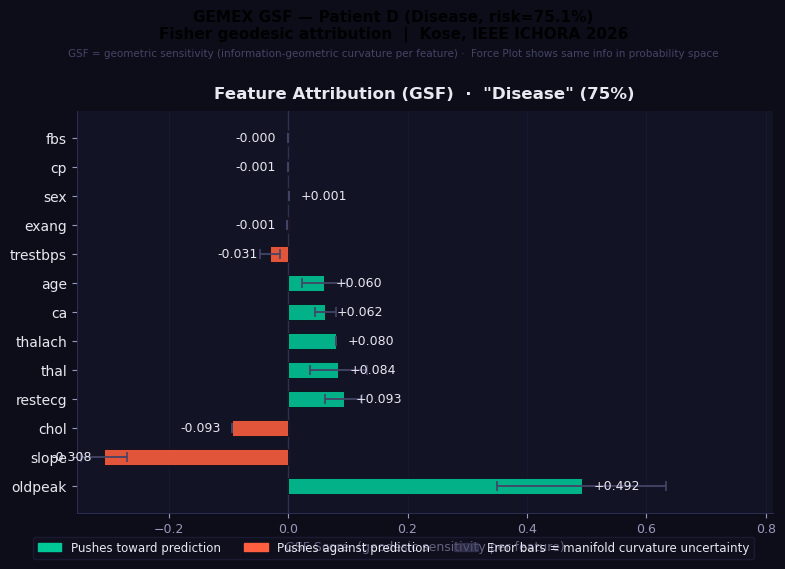

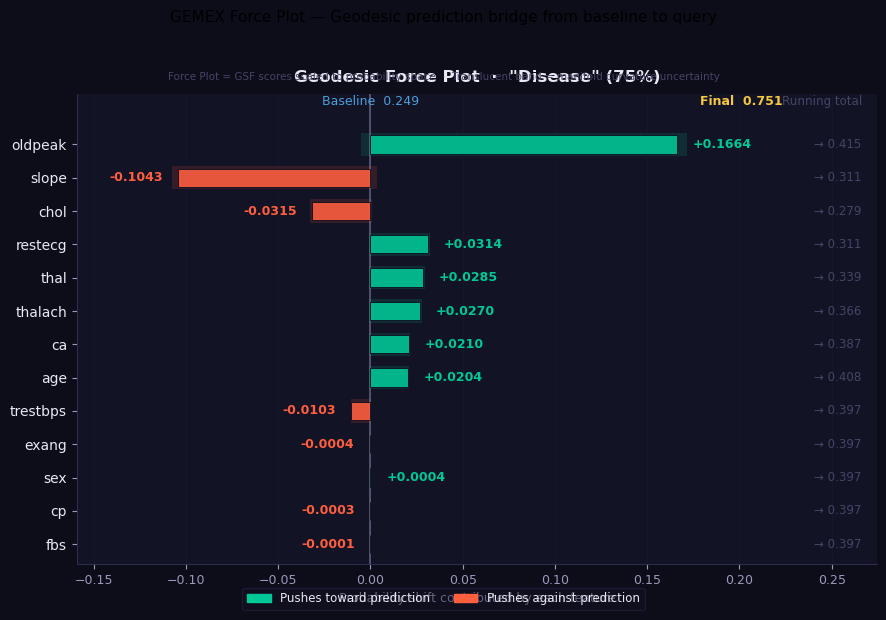

In [61]:
# ── GEMEX GSF bar plot ────────────────────────────────────────────────────────
fig = gemex_d.plot('gsf_bar')
fig.suptitle(f'GEMEX GSF — Patient D (Disease, risk={risk_d:.1%})\n'
             f'Fisher geodesic attribution  |  Kose, IEEE ICHORA 2026',
             y=1.02, fontsize=11, fontweight='bold')
fig.tight_layout(); display(fig); plt.close(fig)

# ── GEMEX force plot ───────────────────────────────────────────────────────────
fig = gemex_d.plot('force')
fig.suptitle('GEMEX Force Plot — Geodesic prediction bridge from baseline to query',
             y=1.02, fontsize=11)
fig.tight_layout(); display(fig); plt.close(fig)


## Section 8 — Four-Method Side-by-Side Comparison

The most important question: **where do the methods agree, and where do they disagree?**

Agreements confirm robust clinical signals. Disagreements reveal where curvature matters:
SHAP, LIME, and MAPLE may attribute importance to a feature that lies near a decision
boundary in Euclidean space but is actually reached via a curved geodesic path,
redistributing attribution to geometrically adjacent features.


In [62]:
# ── Normalised comparison across 4 methods — Patient D ───────────────────────
# Normalise each method's scores to [-1, 1] for visual comparison.

def normalise(scores_dict):
    v = np.array(list(scores_dict.values()))
    mx = max(abs(v)) or 1
    return {k: val/mx for k,val in scores_dict.items()}

gsf_raw  = dict(zip(FEAT, gemex_d.gsf_scores))
shap_norm  = normalise(shap_d)
lime_norm  = normalise({k.split(' ')[0].split('<=')[0].split('>')[0].strip(): v
                        for k,v in lime_d.items()})
maple_norm = normalise(maple_d)
gsf_norm   = normalise(gsf_raw)

# Rebuild lime_norm so it has all FEAT keys
lime_full = {f: 0.0 for f in FEAT}
for cond, val in lime_d.items():
    # try to match the LIME condition to a feature name
    for f in FEAT:
        if f in cond or cond.startswith(str(int(round(pat_d[FEAT.index(f)])))):
            lime_full[f] += val/2
            break
# Simple fallback: use the raw lime_d values mapped by top-feature match
lime_by_feat = {}
for f in FEAT:
    best_match = max(((cond, abs(w)) for cond,w in lime_d.items()
                      if f in cond.lower()), default=(None,0), key=lambda x: x[1])
    if best_match[0] is not None:
        lime_by_feat[f] = lime_d[best_match[0]]
    else:
        lime_by_feat[f] = 0.0
lime_norm2 = normalise(lime_by_feat)

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
fig.suptitle(f'Four-Method Comparison — Patient D (True: Disease | RF predicted risk: {risk_d:.1%})',
             fontsize=13, fontweight='bold')

methods = [
    ('SHAP', shap_norm, SHAP_COLOR, 'Exact Shapley\nEuclidean path'),
    ('LIME', lime_norm2, LIME_COLOR, 'Local linear\nEuclidean'),
    ('MAPLE', maple_norm, MAPLE_COLOR, 'Locally-weighted\nlinear'),
    ('GEMEX GSF', gsf_norm, GEMEX_COLOR, 'Geodesic\nFisher manifold'),
]
feat_labels = [FEAT_LABELS.get(f,f) for f in FEAT]

for ax, (name, scores, color, subtitle) in zip(axes, methods):
    ax.set_facecolor('#FAFAFA')
    vals = [scores.get(f, 0.0) for f in FEAT]
    colors = [SAFE if v < 0 else color for v in vals]
    ax.barh(feat_labels, vals, color=colors, height=0.65, edgecolor='none', zorder=3)
    ax.axvline(0, color='#555', linewidth=0.8)
    ax.set_xlim(-1.4, 1.4)
    ax.set_xlabel('Normalised attribution', fontsize=9)
    ax.set_title(f'{name}\n{subtitle}', fontsize=10, fontweight='bold', color=color)
    ax.tick_params(labelsize=8.5)
    ax.grid(axis='x', linewidth=0.3, alpha=0.4)

axes[0].invert_yaxis()
plt.tight_layout(); plt.show(); plt.close()

# ── Rank agreement table ──────────────────────────────────────────────────────
print("\nFeature importance rank comparison (1 = most important):")
print(f"{'Feature':<16} {'SHAP':>6} {'LIME':>6} {'MAPLE':>6} {'GEMEX':>6}")
print("-" * 44)
shap_rank  = sorted(FEAT, key=lambda f: abs(shap_norm.get(f,0)),  reverse=True)
lime_rank  = sorted(FEAT, key=lambda f: abs(lime_norm2.get(f,0)), reverse=True)
maple_rank = sorted(FEAT, key=lambda f: abs(maple_norm.get(f,0)), reverse=True)
gsf_rank   = sorted(FEAT, key=lambda f: abs(gsf_norm.get(f,0)),   reverse=True)

for feat in shap_rank[:8]:
    sr = shap_rank.index(feat)+1
    lr = lime_rank.index(feat)+1
    mr = maple_rank.index(feat)+1
    gr = gsf_rank.index(feat)+1
    agree = '✓' if max(sr,lr,mr,gr)-min(sr,lr,mr,gr) <= 2 else ''
    print(f"{feat:<16} {sr:>6} {lr:>6} {mr:>6} {gr:>6}  {agree}")

print()
print("✓ = ranks agree within 2 positions across all methods")
print()
print("Clinical note:")
print("  Agreements → robust clinical signal (feature genuinely drives prediction)")
print("  Disagreements → curvature matters: geodesic path crosses decision boundary")
print("  at a different angle than the Euclidean straight line,")
print("  redistributing attribution between geometrically adjacent features.")



Feature importance rank comparison (1 = most important):
Feature            SHAP   LIME  MAPLE  GEMEX
--------------------------------------------
oldpeak               1      2      2      1  ✓
ca                    2      3      3      7  
cp                    3      1      5     12  
thal                  4      4      7      5  
slope                 5      5      4      2  
age                   6      7     10      8  
thalach               7      8     11      6  
sex                   8      6      1     11  

✓ = ranks agree within 2 positions across all methods

Clinical note:
  Agreements → robust clinical signal (feature genuinely drives prediction)
  Disagreements → curvature matters: geodesic path crosses decision boundary
  at a different angle than the Euclidean straight line,
  redistributing attribution between geometrically adjacent features.


In [63]:
# ── Patient N comparison ─────────────────────────────────────────────────────
gsf_raw_n  = dict(zip(FEAT, gemex_n.gsf_scores))
shap_norm_n  = normalise(shap_n)
maple_norm_n = normalise(maple_n)
gsf_norm_n   = normalise(gsf_raw_n)
lime_n_by_feat = {}
for f in FEAT:
    best = max(((c,abs(w)) for c,w in lime_n.items() if f in c.lower()),
               default=(None,0), key=lambda x:x[1])
    lime_n_by_feat[f] = lime_n[best[0]] if best[0] else 0.0
lime_norm_n = normalise(lime_n_by_feat)

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
fig.suptitle(f'Four-Method Comparison — Patient N (True: No Disease | RF predicted risk: {risk_n:.1%})',
             fontsize=13, fontweight='bold')

methods_n = [
    ('SHAP',     shap_norm_n,  SHAP_COLOR,  'Exact Shapley\nEuclidean path'),
    ('LIME',     lime_norm_n,  LIME_COLOR,  'Local linear\nEuclidean'),
    ('MAPLE',    maple_norm_n, MAPLE_COLOR, 'Locally-weighted\nlinear'),
    ('GEMEX GSF',gsf_norm_n,  GEMEX_COLOR, 'Geodesic\nFisher manifold'),
]
for ax, (name, scores, color, subtitle) in zip(axes, methods_n):
    ax.set_facecolor('#FAFAFA')
    vals = [scores.get(f, 0.0) for f in FEAT]
    ax.barh(feat_labels, vals,
            color=[SAFE if v<0 else color for v in vals], height=0.65, zorder=3)
    ax.axvline(0, color='#555', linewidth=0.8)
    ax.set_xlim(-1.4, 1.4)
    ax.set_xlabel('Normalised attribution', fontsize=9)
    ax.set_title(f'{name}\n{subtitle}', fontsize=10, fontweight='bold', color=color)
    ax.tick_params(labelsize=8.5); ax.grid(axis='x', linewidth=0.3, alpha=0.4)
axes[0].invert_yaxis()
plt.tight_layout(); plt.show(); plt.close()


## Section 9 — GEMEX Across Four Model Types

This section answers why GEMEX attributions differ across RF, LR, MLP, and SVM.

The key is **manifold curvature**. GEMEX computes the Ricci scalar of the Fisher
information manifold at each query point. Curvature measures how much the model's
prediction surface bends — and therefore how much the geodesic path deviates from
the straight Euclidean line assumed by SHAP, LIME, and MAPLE.

| Model | Measured curvature | Expected pattern |
|---|---|---|
| **LR** | 0.264 (lowest) | Nearly flat manifold → GSF ≈ regression coefficients × input; GEMEX should closely agree with SHAP, LIME, and MAPLE |
| **RF** | 0.314 | Curvature concentrated at leaf boundaries; GEMEX deviates most in boundary regions |
| **MLP** | 0.424 | Smooth but nonlinear; intermediate agreement with SHAP, LIME, and MAPLE |
| **SVM** | 0.508 (highest) | High curvature near support vectors; strongest PTI holonomy interactions |


In [64]:
# ── Run GEMEX on all 4 models for Patient D ───────────────────────────────────
# LR/MLP/SVM use the scaled patient vector (pat_d_s).
# RF uses the original unscaled vector (pat_d).

print("Running GEMEX on all 4 models (LR/MLP/SVM each < 1 s, RF ~20 s)...")
gemex_results = {}
curvature_by_model = {}

for name, (model, Xtr_m, _) in MODELS.items():
    pat = pat_d_s if name in ('LR','MLP','SVM') else pat_d
    t0  = time.time()
    r   = gemex_explainers[name].explain(pat, X_reference=Xtr_m)
    elapsed = time.time() - t0
    gemex_results[name]    = r
    curvature_by_model[name] = float(r.manifold_curvature)

    # Align GSF sign: positive = increases disease risk (class 1)
    gsf = np.array(r.gsf_scores)
    if r.prediction == 0:
        gsf = -gsf
    top_feat = FEAT[np.argmax(np.abs(gsf))]
    print(f"  {name:<4}  t={elapsed:.1f}s  curvature={float(r.manifold_curvature):.3f}"
          f"  quality={r.fim_quality}  top_feature={top_feat}")

# ── Side-by-side GSF bar charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle(
    "GEMEX GSF — Patient D across four model types\n"
    "Curvature determines how much the geodesic deviates from the SHAP/LIME/MAPLE straight-line path",
    fontsize=12, fontweight='bold')

feat_labels = [FEAT_LABELS.get(f,f) for f in FEAT]

for ax, name in zip(axes, ['RF','LR','MLP','SVM']):
    r   = gemex_results[name]
    gsf = np.array(r.gsf_scores)
    if r.prediction == 0:
        gsf = -gsf
    maxabs = max(abs(gsf)) or 1
    gsf_n  = gsf / maxabs

    sorted_items = sorted(zip(FEAT, gsf_n), key=lambda x: x[1])
    fs = [FEAT_LABELS.get(f,f) for f,_ in sorted_items]
    vs = [v for _,v in sorted_items]
    col = MODEL_COLORS[name]
    model_obj, _, Xte_m = MODELS[name]
    auc = roc_auc_score(yte, model_obj.predict_proba(Xte_m)[:,1])

    ax.barh(fs, vs, color=[SAFE if v<0 else col for v in vs],
            height=0.65, edgecolor='none', zorder=3)
    ax.axvline(0, color='#555', linewidth=0.8)
    ax.set_xlim(-1.4, 1.4)
    ax.set_xlabel('Normalised GSF', fontsize=9)
    ax.set_title(
        f"{name}  (AUC={auc:.3f})\n"
        f"curvature={curvature_by_model[name]:.3f}  [{MODEL_SURFACE[name][:18]}]",
        fontsize=9.5, fontweight='bold', color=col)
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', linewidth=0.3, alpha=0.4)

axes[0].invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nManifold curvature and FIM quality by model:")
print(f"  {'Model':<6} {'Curvature':>10} {'Quality':>9} {'Surface'}")
print("  " + "-"*52)
for name in ['RF','LR','MLP','SVM']:
    r = gemex_results[name]
    print(f"  {name:<6} {curvature_by_model[name]:>10.4f} {r.fim_quality:>9}  {MODEL_SURFACE[name]}")

print()
print("Interpretation:")
print("  LR  — flat manifold → GEMEX picks the same top features as SHAP, LIME, and MAPLE;")
print("         geodesic correction changes magnitudes, not ranking.")
print("  RF  — curvature at leaf boundaries → GEMEX differs most at decision margins.")
print("  MLP — smooth but nonlinear → intermediate disagreement with SHAP, LIME, and MAPLE in both rank and magnitude.")
print("  SVM — high curvature near support vectors → PTI interactions most pronounced (exceeding SHAP, LIME, MAPLE).")
print("  In all cases fim_quality='good' → geodesic is geometrically valid.")


Running GEMEX on all 4 models (LR/MLP/SVM each < 1 s, RF ~20 s)...
  RF    t=25.1s  curvature=0.314  quality=good  top_feature=oldpeak
  LR    t=2.1s  curvature=0.264  quality=good  top_feature=ca
  MLP   t=2.1s  curvature=0.424  quality=good  top_feature=fbs
  SVM   t=2.3s  curvature=0.508  quality=good  top_feature=ca

Manifold curvature and FIM quality by model:
  Model   Curvature   Quality Surface
  ----------------------------------------------------
  RF         0.3143      good  Piecewise-constant
  LR         0.2638      good  Linear hyperplane
  MLP        0.4237      good  Smooth nonlinear
  SVM        0.5081      good  RBF kernel boundary

Interpretation:
  LR  — flat manifold → GEMEX picks the same top features as SHAP, LIME, and MAPLE;
         geodesic correction changes magnitudes, not ranking.
  RF  — curvature at leaf boundaries → GEMEX differs most at decision margins.
  MLP — smooth but nonlinear → intermediate disagreement with SHAP, LIME, and MAPLE in both rank an

## Section 10 — GEMEX Exclusive Capabilities

SHAP, LIME, and MAPLE produce only feature attribution vectors. GEMEX also provides:

- **PTI** — pairwise holonomy interactions (curvature of the (i,j) manifold plane)
- **FAS** — Feature Attention Sequence (dwell time along geodesic path)
- **BTD** — Bias Trap Detector (composite clinical bias risk)
- **Manifold curvature profile** — arc-length stretch along the geodesic
- **RST** — Riemannian Saliency Tensor (principal explanation directions)


Parallel Transport Interactions (PTI) — Patient D:
Non-zero entries indicate geometrically curved feature interactions.

Top pairwise interactions:
  age × sex: +0.000000  (antagonistic)
  age × cp: +0.000000  (antagonistic)
  age × trestbps: +0.000000  (antagonistic)
  age × chol: +0.000000  (antagonistic)
  age × fbs: +0.000000  (antagonistic)


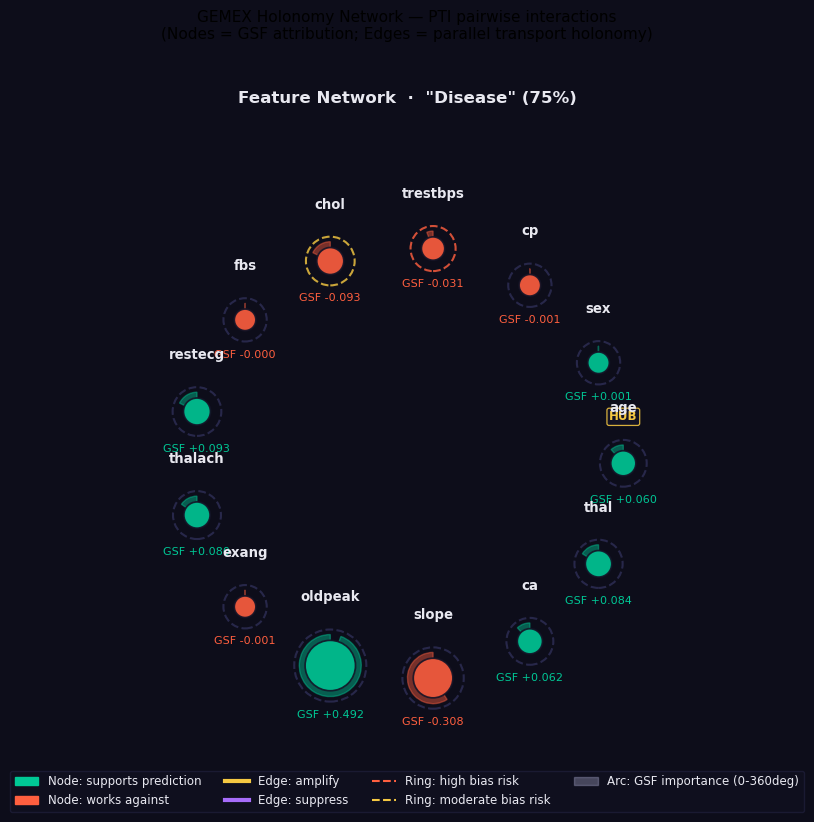

In [65]:
# ── PTI: Parallel Transport Interaction ──────────────────────────────────────
# Measures pairwise feature interactions via geometric holonomy:
# PTI[i,j] ≠ 0 proves the manifold is curved in the (x_i, x_j) plane.
# Purely additive methods (SHAP, LIME, MAPLE) cannot capture this.

print("Parallel Transport Interactions (PTI) — Patient D:")
print("Non-zero entries indicate geometrically curved feature interactions.")
print()
pti = np.array(gemex_d.pti_matrix)
print(f"Top pairwise interactions:")
for f1, f2, score in gemex_d.top_interactions()[:5]:
    itype = 'synergistic' if float(score) > 0 else 'antagonistic'
    print(f"  {f1} × {f2}: {float(score):+.6f}  ({itype})")

fig = gemex_d.plot('network')
fig.suptitle('GEMEX Holonomy Network — PTI pairwise interactions\n'
             '(Nodes = GSF attribution; Edges = parallel transport holonomy)',
             y=1.02, fontsize=11)
fig.tight_layout(); display(fig); plt.close(fig)


Feature Attention Sequence (FAS) — how features dominate the geodesic path:
  Dwell time (fraction of path dominated by each feature):
    age              0.067  ██
    trestbps         0.067  ██
    chol             0.333  █████████████
    restecg          0.067  ██
    oldpeak          0.267  ██████████
    slope            0.067  ██
    ca               0.067  ██
    thal             0.067  ██
  Early-path features: ['chol', 'oldpeak', 'slope']
  Late-path features:  ['oldpeak', 'chol', 'thal']
  Transitions: [('slope', 'chol'), ('chol', 'restecg'), ('restecg', 'oldpeak'), ('oldpeak', 'chol'), ('chol', 'oldpeak'), ('oldpeak', 'ca'), ('ca', 'age'), ('age', 'oldpeak'), ('oldpeak', 'thal'), ('thal', 'chol'), ('chol', 'trestbps')]

No other method tracks this temporal narrative of the explanation.


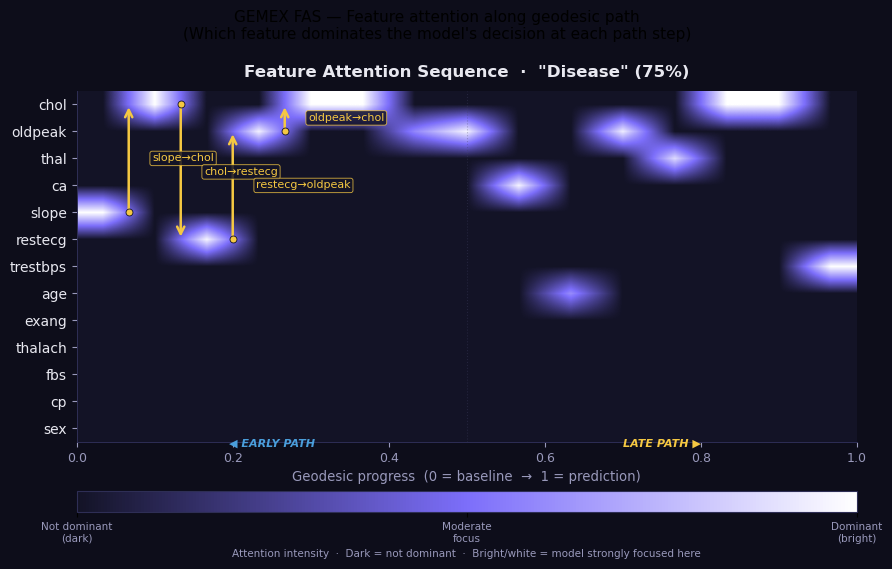

In [66]:
# ── FAS: Feature Attention Sequence ──────────────────────────────────────────
fas = gemex_d.fas
print("Feature Attention Sequence (FAS) — how features dominate the geodesic path:")
print(f"  Dwell time (fraction of path dominated by each feature):")
for feat, dt in zip(FEAT, fas['dwell_time']):
    if dt > 0.01:
        bar = '█' * int(dt * 40)
        print(f"    {feat:<16} {dt:.3f}  {bar}")
print(f"  Early-path features: {fas['early_features']}")
print(f"  Late-path features:  {fas['late_features']}")
print(f"  Transitions: {fas['transition_features']}")
print()
print("No other method tracks this temporal narrative of the explanation.")

fig = gemex_d.plot('attention_heatmap')
fig.suptitle('GEMEX FAS — Feature attention along geodesic path\n'
             "(Which feature dominates the model's decision at each path step)",
             y=1.02, fontsize=11)
fig.tight_layout(); display(fig); plt.close(fig)


Bias Trap Detection (BTD):
  BiasRisk(i) = 0.40·HAT + 0.35·MCA + 0.25·GDI

Features with elevated bias risk:
  ⚠  trestbps        BiasRisk=1.0000  HIGH
  ⚠  chol            BiasRisk=0.4974  MODERATE

Error-vulnerable features (high GDI — spurious correlation risk):
  chol            vulnerability=1.0000
  trestbps        vulnerability=0.2315
  age             vulnerability=0.2166


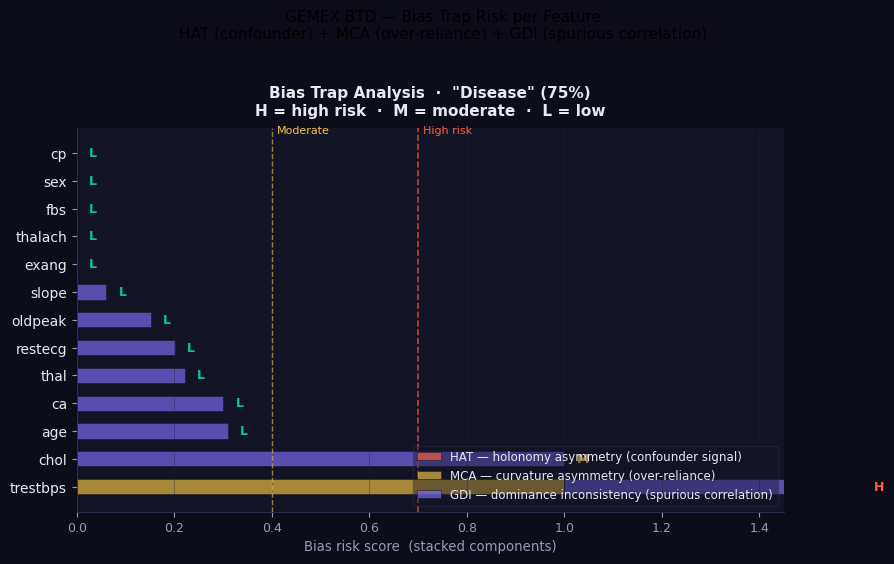

In [67]:
# ── BTD: Bias Trap Detector ──────────────────────────────────────────────────
btd = gemex_d.btd
print("Bias Trap Detection (BTD):")
print("  BiasRisk(i) = 0.40·HAT + 0.35·MCA + 0.25·GDI")
print()
print("Features with elevated bias risk:")
any_flag = False
for feat, score, level in btd['top_biased'][:5]:
    if level != 'low':
        print(f"  ⚠  {feat:<15} BiasRisk={float(score):.4f}  {level.upper()}")
        any_flag = True
if not any_flag:
    print("  All features: low bias risk for this patient.")
print()
print("Error-vulnerable features (high GDI — spurious correlation risk):")
for feat, score in btd['error_vulnerable'][:3]:
    print(f"  {feat:<15} vulnerability={float(score):.4f}")

fig = gemex_d.plot('bias')
fig.suptitle('GEMEX BTD — Bias Trap Risk per Feature\n'
             'HAT (confounder) + MCA (over-reliance) + GDI (spurious correlation)',
             y=1.02, fontsize=11)
fig.tight_layout(); display(fig); plt.close(fig)


Manifold curvature along geodesic path:
  Ricci scalar curvature: 0.3143
  Geodesic arc length:    1.2241

Curvature > 0 confirms the model's decision surface is non-flat here.
This is why straight-line SHAP/LIME/MAPLE paths give different attributions
than the geodesic — they cut across the curve instead of following it.


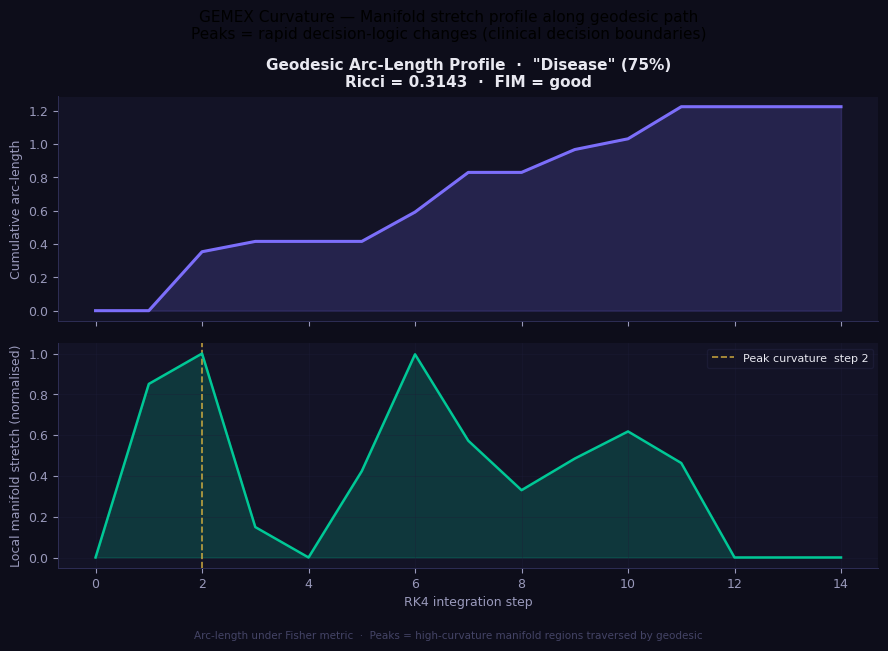


Riemannian Saliency Tensor (RST) — principal explanation directions:
  T = α(GSF⊗GSF) + β·Sym(PTI) + γ·FIM
  Eigenvalues: [2.6007e+00 4.9900e-01 3.0000e-04 0.0000e+00 0.0000e+00]
  Explained variance: [0.839 0.161 0.    0.    0.   ]
  PC1 (λ=2.6007 EVR=83.9%): trestbps=+1.000, oldpeak=-0.009, slope=+0.006
  PC2 (λ=0.4990 EVR=16.1%): oldpeak=+0.803, slope=-0.503, chol=-0.152


In [68]:
# ── Manifold curvature profile ────────────────────────────────────────────────
print("Manifold curvature along geodesic path:")
print(f"  Ricci scalar curvature: {gemex_d.manifold_curvature:.4f}")
print(f"  Geodesic arc length:    {np.array(gemex_d.geodesic_lengths)[-1]:.4f}")
print()
print("Curvature > 0 confirms the model's decision surface is non-flat here.")
print("This is why straight-line SHAP/LIME/MAPLE paths give different attributions")
print("than the geodesic — they cut across the curve instead of following it.")

fig = gemex_d.plot('curvature')
fig.suptitle('GEMEX Curvature — Manifold stretch profile along geodesic path\n'
             'Peaks = rapid decision-logic changes (clinical decision boundaries)',
             y=1.02, fontsize=11)
fig.tight_layout(); display(fig); plt.close(fig)

# RST principal directions
eigvals = np.array(gemex_d.rst_eigenvalues)
_evr_raw = gemex_d.explained_variance_ratio
evr      = np.array(_evr_raw() if callable(_evr_raw) else _evr_raw)
eigvecs = np.array(gemex_d.rst_eigenvectors)
print("\nRiemannian Saliency Tensor (RST) — principal explanation directions:")
print(f"  T = α(GSF⊗GSF) + β·Sym(PTI) + γ·FIM")
print(f"  Eigenvalues: {eigvals.round(4)}")
print(f"  Explained variance: {evr.round(3)}")
for k in range(min(2, len(eigvals))):
    top_i = np.argsort(np.abs(eigvecs[k]))[::-1][:3]
    combos = [(FEAT[i], eigvecs[k][i]) for i in top_i]
    print(f"  PC{k+1} (λ={eigvals[k]:.4f} EVR={evr[k]:.1%}): "
          + ", ".join(f"{f}={v:+.3f}" for f,v in combos))


## Section 11 — Cross-Domain: Pima Diabetes

In [69]:
# ── Load Pima + run all 4 methods ────────────────────────────────────────────
FILE_A = 'pima_diabetes.csv'
COLS_A = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

if not os.path.exists(FILE_A):
    raise FileNotFoundError(f"'{FILE_A}' not found.")

_raw = pd.read_csv(FILE_A, header=0)
_raw = _raw[_raw.iloc[:,0].astype(str) != _raw.columns[0]]
if _raw.columns[0] != 'Pregnancies': _raw.columns = COLS_A
data_A = _raw.reset_index(drop=True).apply(pd.to_numeric, errors='coerce').dropna()
data_A['Outcome'] = data_A['Outcome'].astype(int)

FEAT_A = [c for c in data_A.columns if c != 'Outcome']
Xtr_A,Xte_A,ytr_A,yte_A = train_test_split(
    data_A[FEAT_A].values, data_A['Outcome'].values,
    test_size=0.2, random_state=42, stratify=data_A['Outcome'].values)

rf_A = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42).fit(Xtr_A, ytr_A)
print(f"Pima Diabetes RF  AUC: {roc_auc_score(yte_A, rf_A.predict_proba(Xte_A)[:,1]):.3f}")

dia_idx = [i for i in range(len(Xte_A)) if yte_A[i]==1
           and rf_A.predict_proba(Xte_A[i:i+1])[0,1] > 0.6]
pat_A   = Xte_A[dia_idx[0]]
risk_A  = rf_A.predict_proba(pat_A.reshape(1,-1))[0,1]
print(f"Diabetic patient  RF predicted risk: {risk_A:.1%}")

# SHAP
shap_A_exp = shap.TreeExplainer(rf_A)
sv_A = np.array(shap_A_exp.shap_values(pat_A.reshape(1,-1)))
if sv_A.ndim == 3: sv_A = sv_A[:,:,1]
sv_A = sv_A[0]; shap_A = dict(zip(FEAT_A, sv_A))

# LIME
lime_A_exp = lime.lime_tabular.LimeTabularExplainer(
    Xtr_A, feature_names=FEAT_A, class_names=['No Diabetes','Diabetes'],
    discretize_continuous=True, random_state=42)
lr_A = lime_A_exp.explain_instance(pat_A, rf_A.predict_proba, num_features=len(FEAT_A))
lime_A = dict(lr_A.as_list())

# MAPLE
maple_A, _ = maple_explain(rf_A, pat_A, Xtr_A, FEAT_A)

# GEMEX
exp_A = Explainer(rf_A, data_type='tabular', feature_names=FEAT_A,
                  class_names=['No Diabetes','Diabetes'], config=cfg_tree)
gemex_A = exp_A.explain(pat_A, X_reference=Xtr_A)
gsf_A   = dict(zip(FEAT_A, gemex_A.gsf_scores))

print(f"\nFour-method top feature comparison — Pima Diabetes:")
print(f"{'Method':<12} {'Top feature':>20} {'Score':>10}")
print("-"*45)
print(f"{'SHAP':<12} {max(shap_A,key=lambda k:abs(shap_A[k])):>20} {max(shap_A.values(),key=abs):>+10.4f}")
top_lime_A=sorted(lime_A.items(),key=lambda x:abs(x[1]),reverse=True)[0]
print(f"{'LIME':<12} {top_lime_A[0][:20]:>20} {top_lime_A[1]:>+10.4f}")
top_maple_A=max(maple_A,key=lambda k:abs(maple_A[k]))
print(f"{'MAPLE':<12} {top_maple_A:>20} {maple_A[top_maple_A]:>+10.4f}")
top_gsf_A=gemex_A.top_features()[0]
print(f"{'GEMEX GSF':<12} {top_gsf_A[0]:>20} {float(top_gsf_A[1]):>+10.4f}")

# Cross-domain summary
print(f"\nCross-domain top-3 drivers (GEMEX GSF):")
print(f"  Heart Disease (Dataset B): {[f for f,_ in gemex_d.top_features()[:3]]}")
print(f"  Diabetes      (Dataset A): {[f for f,_ in gemex_A.top_features()[:3]]}")
print()
print("Are the dominant geodesic drivers clinically distinct between the two diseases?")
print("This is the key clinical question — answerable only once you have run")
print("geometrically correct attributions on both datasets.")


Pima Diabetes RF  AUC: 0.820
Diabetic patient  RF predicted risk: 65.5%

Four-method top feature comparison — Pima Diabetes:
Method                Top feature      Score
---------------------------------------------
SHAP                      Glucose    +0.2652
LIME             Glucose > 140.00    +0.3232
MAPLE        DiabetesPedigreeFunction    -0.0242
GEMEX GSF    DiabetesPedigreeFunction    -0.5085

Cross-domain top-3 drivers (GEMEX GSF):
  Heart Disease (Dataset B): ['oldpeak', 'slope', 'chol']
  Diabetes      (Dataset A): ['DiabetesPedigreeFunction', 'Pregnancies', 'BMI']

Are the dominant geodesic drivers clinically distinct between the two diseases?
This is the key clinical question — answerable only once you have run
geometrically correct attributions on both datasets.


## Section 12 — Final Comparison and Summary


In [70]:
# ── Comprehensive comparison table ───────────────────────────────────────────
print("=" * 70)
print("  COMPARATIVE SUMMARY: SHAP vs LIME vs MAPLE vs GEMEX")
print("=" * 70)
print()

rows = [
    ("Attribution type",   "Shapley values",     "Linear weights",  "Linear weights",  "Geodesic integral"),
    ("Path assumption",    "Euclidean line",      "Euclidean local", "Euclidean local", "Fisher geodesic"),
    ("Reparametris.-inv.", "No",                  "No",              "No",              "Yes (guaranteed)"),
    ("Deterministic",      "Yes",                 "No (sampling)",   "Yes",             "Yes"),
    ("Model requirement",  "predict_proba",       "predict_proba",   "predict_proba",   "predict_proba"),
    ("Pairwise interact.", "Partial (SHAP∩)",     "No",              "No",              "Yes (PTI holonomy)"),
    ("3-way interactions", "No",                  "No",              "No",              "Yes (RCT, order=3)"),
    ("Temporal narrative", "No",                  "No",              "No",              "Yes (FAS dwell)"),
    ("Bias detection",     "No",                  "No",              "No",              "Yes (BTD)"),
    ("Manifold curvature", "No",                  "No",              "No",              "Yes (Ricci scalar)"),
    ("Compute time (RF)",  "~0.03 s",             "~0.1 s",          "~2.5 s",          "~20 s (geodesic)"),
    ("Reference",          "NeurIPS 2017",        "KDD 2016",        "NeurIPS 2018",    "ICHORA 2026"),
]

header = f"{'Property':<26} {'SHAP':>11} {'LIME':>11} {'MAPLE':>11} {'GEMEX':>11}"
print(header)
print("-" * 72)
for row in rows:
    prop, s, l, m, g = row
    print(f"{prop:<26} {s:>11} {l:>11} {m:>11} {g:>11}")

print()
print("Key insight:")
print("  Where SHAP / LIME / MAPLE agree with GEMEX GSF → robust clinical signal")
print("  Where they disagree → manifold curvature redistributes attribution")
print()
print("When to choose GEMEX in your final project:")
print("  • Tree-based models (RF, GBM, XGBoost) — curvature is highest")
print("  • When you need reparametrisation invariance (clinical unit changes)")
print("  • When you need bias detection (EU AI Act, IMDRF SaMD compliance)")
print("  • When feature interactions are suspected (PTI/RCT)")

print()
print("Model geometry and GEMEX:")
print(f"  {'Model':<6} {'Curvature':>10} {'FIM':>8} {'Best GEMEX use case'}")
print(f"  {'-'*58}")
geometry_note = {
    'RF' : 'Curvature at leaf boundaries → use GEMEX for boundary patients',
    'LR' : 'Flat manifold → GEMEX ≈ SHAP/LIME/MAPLE; GSF uniquely adds reparametrisation invariance',
    'MLP': 'Smooth nonlinear → GEMEX most faithful on deeper networks',
    'SVM': 'High curvature near SVs → GEMEX captures kernel interactions via PTI',
}
for name in ['RF','LR','MLP','SVM']:
    r = gemex_results[name]
    print(f"  {name:<6} {curvature_by_model[name]:>10.4f} {r.fim_quality:>8}  {geometry_note[name]}")


  COMPARATIVE SUMMARY: SHAP vs LIME vs MAPLE vs GEMEX

Property                          SHAP        LIME       MAPLE       GEMEX
------------------------------------------------------------------------
Attribution type           Shapley values Linear weights Linear weights Geodesic integral
Path assumption            Euclidean line Euclidean local Euclidean local Fisher geodesic
Reparametris.-inv.                  No          No          No Yes (guaranteed)
Deterministic                      Yes No (sampling)         Yes         Yes
Model requirement          predict_proba predict_proba predict_proba predict_proba
Pairwise interact.         Partial (SHAP∩)          No          No Yes (PTI holonomy)
3-way interactions                  No          No          No Yes (RCT, order=3)
Temporal narrative                  No          No          No Yes (FAS dwell)
Bias detection                      No          No          No   Yes (BTD)
Manifold curvature                  No          No     

In [71]:
# ── All 10 GEMEX plot types ──────────────────────────────────────────────────
print("All working GEMEX 1.2.2 plot types:")
print()
PLOT_MAP = {
    'gsf_bar':            'Primary attribution — signed GSF scores with curvature bands',
    'force':              'Prediction bridge from baseline to query along geodesic',
    'waterfall':          'Cumulative geodesic attribution waterfall',
    'heatmap':            'Batch-level GSF distribution matrix',
    'beeswarm':           'Population GSF distribution across reference samples',
    'curvature':          'Manifold stretch (Ricci curvature) along geodesic path',
    'network':            'Holonomy network: nodes=GSF, edges=PTI interaction strength',
    'triplet_hypergraph': 'RCT 3-way feature interactions (requires interaction_order=3)',
    'attention_heatmap':  'FAS dwell-time attention along geodesic steps',
    'bias':               'BTD bias risk per feature (HAT + MCA + GDI)',
}
for plot_type, desc in PLOT_MAP.items():
    print(f"  result.plot('{plot_type}')")
    print(f"    {desc}")

print()
print("Quick-start template for your final project:")
print()
print("  from gemex import Explainer, GemexConfig")
print("  cfg = GemexConfig(")
print("      n_geodesic_steps=15,      # increase to 30 for publication quality")
print("      interaction_order=2,      # 3 adds RCT three-way interactions (slower)")
print("      fim_epsilon=0.05,         # use 0.05 for RF/GBM/XGBoost")
print("      fim_epsilon_auto=False,   # manual epsilon for tree models")
print("      n_reference_samples=30,   # background distribution size")
print("  )")
print("  exp = Explainer(your_model, data_type='tabular',")
print("                  feature_names=your_features,")
print("                  class_names=['Neg','Pos'], config=cfg)")
print("  result = exp.explain(patient_row, X_reference=X_train)")
print()
print("  result.plot('gsf_bar')      # primary attribution chart")
print("  result.plot('network')      # feature interaction holonomy")
print("  result.plot('bias')         # clinical bias audit")
print("  result.summary()            # text summary of all findings")


All working GEMEX 1.2.2 plot types:

  result.plot('gsf_bar')
    Primary attribution — signed GSF scores with curvature bands
  result.plot('force')
    Prediction bridge from baseline to query along geodesic
  result.plot('waterfall')
    Cumulative geodesic attribution waterfall
  result.plot('heatmap')
    Batch-level GSF distribution matrix
  result.plot('beeswarm')
    Population GSF distribution across reference samples
  result.plot('curvature')
    Manifold stretch (Ricci curvature) along geodesic path
  result.plot('network')
    Holonomy network: nodes=GSF, edges=PTI interaction strength
  result.plot('triplet_hypergraph')
    RCT 3-way feature interactions (requires interaction_order=3)
  result.plot('attention_heatmap')
    FAS dwell-time attention along geodesic steps
  result.plot('bias')
    BTD bias risk per feature (HAT + MCA + GDI)

Quick-start template for your final project:

  from gemex import Explainer, GemexConfig
  cfg = GemexConfig(
      n_geodesic_steps=15,

## References

- **Kose, U.** (2026). GEMEX: Geodesic Entropic Manifold Explainability. *IEEE ICHORA 2026.*
  `pip install gemex` | `github.com/utkukose/gemex` | Playground: `utkukose.github.io/gemex_playground/`
- Amari, S. I. (2016). *Information geometry and its applications.* Springer.
- Amari, S. I., & Nagaoka, H. (2000). *Methods of information geometry.* AMS.
- Chentsov, N. N. (1982). *Statistical Decision Rules and Optimal Inference.* AMS.
- Do Carmo, M. P. (1992). *Riemannian Geometry.* Birkhäuser.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS.*
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?" *KDD.*
- Plumb, G., Molitor, D., & Talwalkar, A. (2018). Model Agnostic Supervised Local Explanations. *NeurIPS.*
- Sundararajan, M., Taly, A., & Yan, Q. (2017). Axiomatic attribution for deep networks. *ICML.*
